In [1]:
"""
Weakly Supervised Object Detection (WSOD) Fine-tuning
Uses bounding box annotations to guide attention maps without strict localization
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
# ============================================================================
# GradCAM Implementation
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        """Generate CAM for given input"""
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1)
        
        # Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot.scatter_(1, target_class.unsqueeze(1), 1.0)
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Generate CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        
        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam

In [3]:
# ============================================================================
# WSOD Model with Attention Loss
# ============================================================================

class WSODModel(nn.Module):
    def __init__(self, base_model, num_classes=2):
        super(WSODModel, self).__init__()
        self.base_model = base_model
        self.num_classes = num_classes
        
        # Check if base_model is ResNetWithMultiScaleAttention or standard ResNet
        if hasattr(base_model, 'stage4'):
            # Custom ResNetWithMultiScaleAttention
            self.target_layer = base_model.stage4[-1]
            self.is_custom_resnet = True
        else:
            # Standard ResNet
            self.target_layer = base_model.layer4[-1]
            self.is_custom_resnet = False
        
    def forward(self, x):
        return self.base_model(x)
    
    def get_attention_map(self, x):
        """Get attention map from last conv layer"""
        if self.is_custom_resnet:
            # For ResNetWithMultiScaleAttention
            features = self.base_model.stem(x)
            features = self.base_model.stage1(features)
            features = self.base_model.trans1(features)
            features = self.base_model.stage2(features)
            features = self.base_model.trans2(features)
            features = self.base_model.stage3(features)
            features = self.base_model.trans3(features)
            features = self.base_model.stage4(features)
            features = self.base_model.trans4(features)
            
            # Get attention from final features
            attention = features.mean(dim=1, keepdim=True)
        else:
            # For standard ResNet
            features = x
            for name, module in self.base_model.named_children():
                features = module(features)
                if name == 'layer4':
                    attention = features.mean(dim=1, keepdim=True)
                    break
        
        # Normalize attention
        attention = F.relu(attention)
        attention = attention - attention.min()
        attention = attention / (attention.max() + 1e-8)
        
        return attention

In [4]:
# ============================================================================
# Attention-based Loss Functions
# ============================================================================

def bbox_to_gaussian_mask(bbox, target_size=(7, 7), sigma_scale=1.5):
    """
    Convert bounding box to Gaussian mask for soft attention guidance
    Args:
        bbox: [x, y, w, h] in normalized coordinates [0, 1]
        target_size: Size of attention map (H, W)
        sigma_scale: Controls Gaussian spread (larger = more relaxed)
    """
    batch_size = bbox.shape[0]
    h, w = target_size
    
    # Create coordinate grids
    y_coords = torch.linspace(0, 1, h, device=bbox.device).view(-1, 1).expand(h, w)
    x_coords = torch.linspace(0, 1, w, device=bbox.device).view(1, -1).expand(h, w)
    
    masks = []
    for i in range(batch_size):
        x, y, box_w, box_h = bbox[i]
        
        # Center of bounding box
        cx = x + box_w / 2
        cy = y + box_h / 2
        
        # Sigma based on box size (larger boxes = wider Gaussian)
        sigma_x = (box_w / 2) * sigma_scale
        sigma_y = (box_h / 2) * sigma_scale
        
        # Prevent division by zero
        sigma_x = max(sigma_x, 0.05)
        sigma_y = max(sigma_y, 0.05)
        
        # Gaussian formula
        gaussian = torch.exp(
            -((x_coords - cx) ** 2) / (2 * sigma_x ** 2) -
            ((y_coords - cy) ** 2) / (2 * sigma_y ** 2)
        )
        
        masks.append(gaussian)
    
    return torch.stack(masks).unsqueeze(1)  # [B, 1, H, W]


def attention_bbox_loss(attention_map, bbox, label, loss_weight=0.3, sigma_scale=1.5):
    """
    Attention loss that guides model to focus on bbox region
    Only applied to positive samples (nodules present)
    
    Args:
        attention_map: [B, 1, H, W] attention from model
        bbox: [B, 4] bounding boxes in normalized coords
        label: [B] binary labels (0 or 1)
        loss_weight: Weight for attention loss
        sigma_scale: Controls how strict the localization is (larger = more relaxed)
    """
    # Only compute loss for positive samples
    positive_mask = label == 1
    
    if positive_mask.sum() == 0:
        return torch.tensor(0.0, device=attention_map.device)
    
    # Get positive samples
    pos_attention = attention_map[positive_mask]
    pos_bbox = bbox[positive_mask]
    
    # Upsample attention to reasonable size for loss computation
    target_size = (14, 14)  # Intermediate resolution
    pos_attention_up = F.interpolate(
        pos_attention, 
        size=target_size, 
        mode='bilinear', 
        align_corners=False
    )
    
    # Generate Gaussian masks from bboxes
    gaussian_masks = bbox_to_gaussian_mask(pos_bbox, target_size, sigma_scale)
    
    # MSE loss between attention and Gaussian mask
    mse_loss = F.mse_loss(pos_attention_up, gaussian_masks)
    
    # Alternative: KL divergence (treating as probability distributions)
    # Normalize to probability distributions
    attention_prob = pos_attention_up / (pos_attention_up.sum(dim=(2, 3), keepdim=True) + 1e-8)
    target_prob = gaussian_masks / (gaussian_masks.sum(dim=(2, 3), keepdim=True) + 1e-8)
    
    kl_loss = F.kl_div(
        (attention_prob + 1e-8).log(), 
        target_prob, 
        reduction='batchmean'
    )
    
    # Combine losses
    total_attention_loss = loss_weight * (0.5 * mse_loss + 0.5 * kl_loss)
    
    return total_attention_loss

In [5]:
# ============================================================================
# Training Functions
# ============================================================================

def train_epoch_wsod(model, loader, criterion, optimizer, device, attention_weight=0.3):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training WSOD')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Classification loss
        cls_loss = criterion(outputs, labels)
        
        # Attention loss
        attention_map = model.get_attention_map(images)
        att_loss = attention_bbox_loss(attention_map, bboxes, labels, attention_weight)
        
        # Total loss
        loss = cls_loss + att_loss
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_cls_loss += cls_loss.item()
        running_att_loss += att_loss.item()
        
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({
            'loss': running_loss/len(pbar),
            'cls': running_cls_loss/len(pbar),
            'att': running_att_loss/len(pbar),
            'acc': 100.*correct/total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_cls_loss = running_cls_loss / len(loader)
    epoch_att_loss = running_att_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_cls_loss, epoch_att_loss, epoch_acc, all_preds, all_labels, all_probs

def validate_wsod(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs, binary_precision, binary_recall, binary_f1, binary_auc


In [6]:
# ============================================================================
# Visualization Functions
# ============================================================================

def visualize_attention_with_bbox(model, image, bboxes, label, pred, denormalize=True):
    """
    Visualize attention map overlaid on image with GT bbox(es)
    Args:
        bboxes: can be a single bbox tensor [4] or list of bbox tensors for multiple nodules
    """
    model.eval()
    
    # Denormalize image
    if denormalize:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_display = image.cpu() * std + mean
        image_display = image_display.clamp(0, 1)
    else:
        image_display = image.cpu()
    
    # Get attention map
    with torch.no_grad():
        attention_map = model.get_attention_map(image.unsqueeze(0).to(device))
        attention_map = attention_map.squeeze().cpu().numpy()
    
    # Resize attention to match image
    attention_resized = cv2.resize(attention_map, (224, 224))
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    img_np = image_display.permute(1, 2, 0).numpy()
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original\nGT: {label}, Pred: {pred}')
    axes[0].axis('off')
    
    # Attention heatmap
    axes[1].imshow(img_np)
    im = axes[1].imshow(attention_resized, cmap='jet', alpha=0.5)
    axes[1].set_title('Attention Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    
    # With bounding box(es)
    axes[2].imshow(img_np)
    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5)
    
    # Draw bbox(es) if nodule is present
    if label == 1:
        # Handle both single bbox and list of bboxes
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        for idx, bbox in enumerate(bboxes):
            x, y, w, h = bbox.cpu().numpy()
            # Convert normalized coords to pixel coords
            x_pix = x * 224
            y_pix = y * 224
            w_pix = w * 224
            h_pix = h * 224
            
            color = 'lime'
            rect = plt.Rectangle(
                (x_pix, y_pix), w_pix, h_pix,
                fill=False, edgecolor=color, linewidth=2
            )
            axes[2].add_patch(rect)
        
        axes[2].legend([f'GT BBox ({len(bboxes)} nodule{"s" if len(bboxes) > 1 else ""})'])
    
    axes[2].set_title('Attention + GT BBox')
    axes[2].axis('off')
    
    plt.tight_layout()
    return fig

print("=" * 80)
print("Setup complete! Ready for training.")
print("=" * 80)

Setup complete! Ready for training.


In [7]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BATCH_SIZE = 8
NUM_EPOCHS = 15
LEARNING_RATE = 5e-5  # Lower LR for fine-tuning
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01
ATTENTION_WEIGHT = 0.3  # Weight for attention loss
SIGMA_SCALE = 1.5  # Controls Gaussian spread (1.5 = relaxed, 1.0 = strict)

# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

In [8]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class TransformerBlock(nn.Module):
    """Ultra-lightweight Transformer block with spatial downsampling"""
    def __init__(self, dim, num_heads=2, mlp_ratio=1.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        B, C, H, W = x.shape
        
        # OPTIMIZATION: Downsample spatial dims for attention if too large
        if H * W > 196:  # If feature map > 14x14
            x_down = F.adaptive_avg_pool2d(x, (14, 14))
            B_d, C_d, H_d, W_d = x_down.shape
            x_seq = x_down.flatten(2).transpose(1, 2)
        else:
            x_seq = x.flatten(2).transpose(1, 2)
            H_d, W_d = H, W
        
        # Multi-head self-attention with residual
        x_norm = self.norm1(x_seq)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x_seq = x_seq + attn_out
        
        # MLP with residual
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        
        # Reshape back
        x_out = x_seq.transpose(1, 2).reshape(B, C, H_d, W_d)
        
        # Upsample back if needed
        if H_d != H or W_d != W:
            x_out = F.interpolate(x_out, size=(H, W), mode='bilinear', align_corners=False)
        
        return x + x_out  # Residual from original

class ResNetWithMultiScaleAttention(nn.Module):
    """ResNet-50 with lightweight transformer blocks at multiple scales"""
    def __init__(self, num_classes=2, pretrained=True, num_heads=2, dropout=0.1):
        super().__init__()
        
        # Load pretrained ResNet-50
        backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        # Extract ResNet stages
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.act1,
            backbone.maxpool
        )
        self.stage1 = backbone.layer1  # Output: 256 channels, H/4 x W/4 (56x56 for 224 input)
        self.stage2 = backbone.layer2  # Output: 512 channels, H/8 x W/8 (28x28)
        self.stage3 = backbone.layer3  # Output: 1024 channels, H/16 x W/16 (14x14)
        self.stage4 = backbone.layer4  # Output: 2048 channels, H/32 x W/32 (7x7)
        
        # Add ultra-lightweight transformer blocks after each stage
        # Using minimal heads and MLP ratio to keep it fast
        self.trans1 = TransformerBlock(256, num_heads=2, mlp_ratio=1.0, dropout=dropout)
        self.trans2 = TransformerBlock(512, num_heads=2, mlp_ratio=1.0, dropout=dropout)
        self.trans3 = TransformerBlock(1024, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)
        self.trans4 = TransformerBlock(2048, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)
        
        # Global average pooling and classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(2048, num_classes)
        
    def forward(self, x):
        # Stem
        x = self.stem(x)
        
        # Stage 1 + Transformer
        x = self.stage1(x)
        x = self.trans1(x)
        
        # Stage 2 + Transformer
        x = self.stage2(x)
        x = self.trans2(x)
        
        # Stage 3 + Transformer
        x = self.stage3(x)
        x = self.trans3(x)
        
        # Stage 4 + Transformer
        x = self.stage4(x)
        x = self.trans4(x)
        
        # Global pooling and classification
        x = self.global_pool(x)
        x = x.flatten(1)
        x = self.classifier(x)
        
        return x

In [10]:
# ============================================================================
# LOAD PRETRAINED MODEL & SETUP WSOD
# ============================================================================

print("\nLoading pretrained checkpoint...")
base_model = ResNetWithMultiScaleAttention(num_classes=2, pretrained=False, num_heads=2, dropout=0.1)
checkpoint_path = "./resvit-two-scale.pth"

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
if 'model_state_dict' in checkpoint:
    base_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Previous val_acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    base_model.load_state_dict(checkpoint)
    print("Loaded model weights")

# Wrap in WSOD model
model = WSODModel(base_model, num_classes=2).to(device)

# Calculate class weights
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"\nClass weights: {class_weights}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("\nModel ready for WSOD fine-tuning!")



Loading pretrained checkpoint...
Loaded checkpoint from epoch 16
Previous val_acc: 94.50%

Class weights: tensor([0.6971, 1.7684], device='cuda:0')

Model ready for WSOD fine-tuning!


In [11]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "=" * 80)
print("Starting WSOD Fine-tuning")
print("=" * 80)

history = {
    'train_loss': [], 'train_cls_loss': [], 'train_att_loss': [],
    'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_f1': []
}

best_val_auc = 0.0
best_model_path = 'best_wsod_resvit.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss, train_cls_loss, train_att_loss, train_acc, train_preds, train_labels, train_probs = train_epoch_wsod(
        model, train_loader, criterion, optimizer, device, ATTENTION_WEIGHT
    )
    
    train_auc = roc_auc_score(train_labels, train_probs)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs, val_prec, val_recall, val_f1, val_auc = validate_wsod(
        model, val_loader, criterion, device
    )
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_cls_loss'].append(train_cls_loss)
    history['train_att_loss'].append(train_att_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    
    print(f"\nTrain - Loss: {train_loss:.4f} (Cls: {train_cls_loss:.4f}, Att: {train_att_loss:.4f})")
    print(f"Train - Acc: {train_acc:.2f}%, AUC: {train_auc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, AUC: {val_auc:.4f}")
    print(f"Val   - Precision: {val_prec:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
            'val_f1': val_f1,
        }, best_model_path)
        print(f"✓ Saved best model (AUC: {val_auc:.4f})")

print("\n" + "=" * 80)
print("Training completed!")
print(f"Best validation AUC: {best_val_auc:.4f}")
print("=" * 80)


Starting WSOD Fine-tuning

Epoch 1/15
--------------------------------------------------------------------------------


Validation: 100%|██████████| 98/98 [00:18<00:00,  5.30it/s]



Train - Loss: 0.8005 (Cls: 0.4112, Att: 0.3893)
Train - Acc: 83.05%, AUC: 0.9047
Val   - Loss: 0.3294, Acc: 86.57%, AUC: 0.9396
Val   - Precision: 0.7174, Recall: 0.8800, F1: 0.7904
LR: 0.000049
✓ Saved best model (AUC: 0.9396)

Epoch 2/15
--------------------------------------------------------------------------------


Validation: 100%|██████████| 98/98 [00:20<00:00,  4.83it/s]



Train - Loss: 0.7483 (Cls: 0.3875, Att: 0.3609)
Train - Acc: 83.54%, AUC: 0.9088
Val   - Loss: 0.4253, Acc: 82.99%, AUC: 0.9433
Val   - Precision: 0.6394, Recall: 0.9378, F1: 0.7604
LR: 0.000048
✓ Saved best model (AUC: 0.9433)

Epoch 3/15
--------------------------------------------------------------------------------


...


Train - Loss: 0.4820 (Cls: 0.1664, Att: 0.3157)
Train - Acc: 93.85%, AUC: 0.9831
Val   - Loss: 0.2245, Acc: 90.92%, AUC: 0.9693
Val   - Precision: 0.8889, Recall: 0.7822, F1: 0.8322
LR: 0.000002
✓ Saved best model (AUC: 0.9693)

Epoch 14/15
--------------------------------------------------------------------------------


Validation: 100%|██████████| 98/98 [00:19<00:00,  4.97it/s]



Train - Loss: 0.4745 (Cls: 0.1590, Att: 0.3155)
Train - Acc: 93.63%, AUC: 0.9846
Val   - Loss: 0.2452, Acc: 90.28%, AUC: 0.9646
Val   - Precision: 0.7922, Recall: 0.8978, F1: 0.8417
LR: 0.000001

Epoch 15/15
--------------------------------------------------------------------------------


Validation: 100%|██████████| 98/98 [00:18<00:00,  5.44it/s]


Train - Loss: 0.5046 (Cls: 0.1821, Att: 0.3225)
Train - Acc: 93.36%, AUC: 0.9803
Val   - Loss: 0.2689, Acc: 88.49%, AUC: 0.9590
Val   - Precision: 0.8610, Recall: 0.7156, F1: 0.7816
LR: 0.000000

Training completed!
Best validation AUC: 0.9693


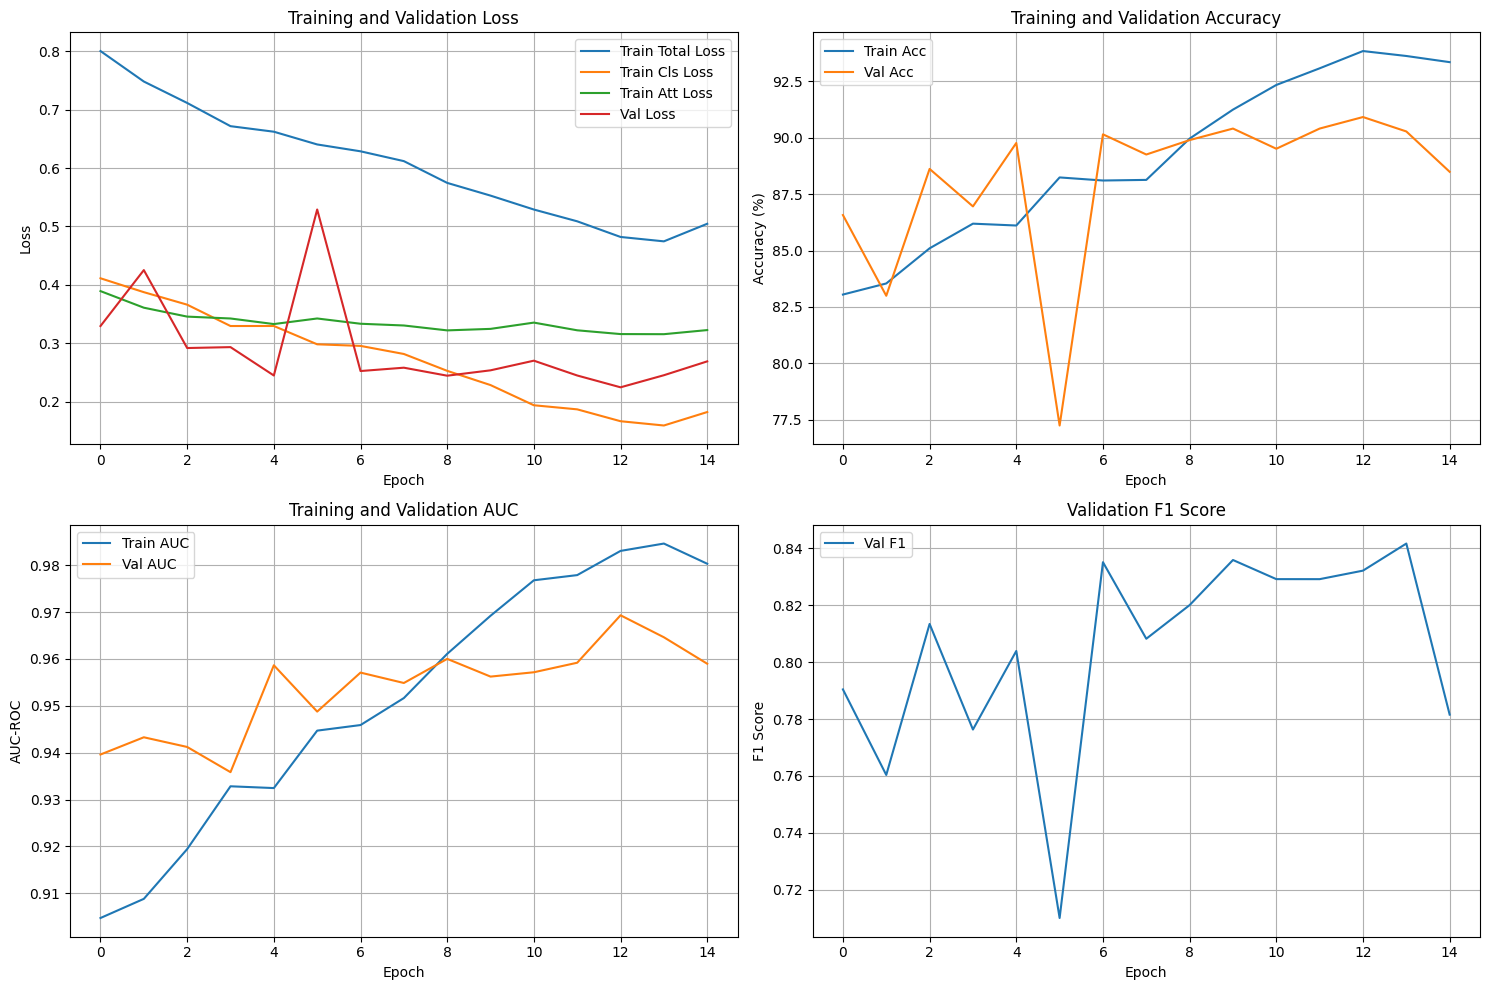

Training curves saved to 'wsod_training_history.png'


In [12]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Total Loss')
axes[0, 0].plot(history['train_cls_loss'], label='Train Cls Loss')
axes[0, 0].plot(history['train_att_loss'], label='Train Att Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc')
axes[0, 1].plot(history['val_acc'], label='Val Acc')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history['train_auc'], label='Train AUC')
axes[1, 0].plot(history['val_auc'], label='Val AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC-ROC')
axes[1, 0].set_title('Training and Validation AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('wsod_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'wsod_training_history.png'")

In [13]:
# ============================================================================
# LOAD BEST MODEL FOR TESTING
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for testing...")
print("=" * 80)

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val AUC: {checkpoint['val_auc']:.4f}")


Loading best model for testing...
Loaded best model from epoch 13
Best val AUC: 0.9693


In [14]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\nEvaluating on test set...")

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_recall, test_f1, test_auc = validate_wsod(
    model, test_loader, criterion, device
)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC-ROC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)



Evaluating on test set...


Validation: 100%|██████████| 99/99 [00:16<00:00,  5.87it/s]


TEST SET RESULTS
Test Loss: 0.2004
Test Accuracy: 91.85%
Test AUC-ROC: 0.9724
Test Precision: 0.8964
Test Recall: 0.7972
Test F1 Score: 0.8439

Confusion Matrix:
[[548  20]
 [ 44 173]]



Generating Attention Visualizations on Test Set
Selected random indices: [714 365 665 284 634  54]


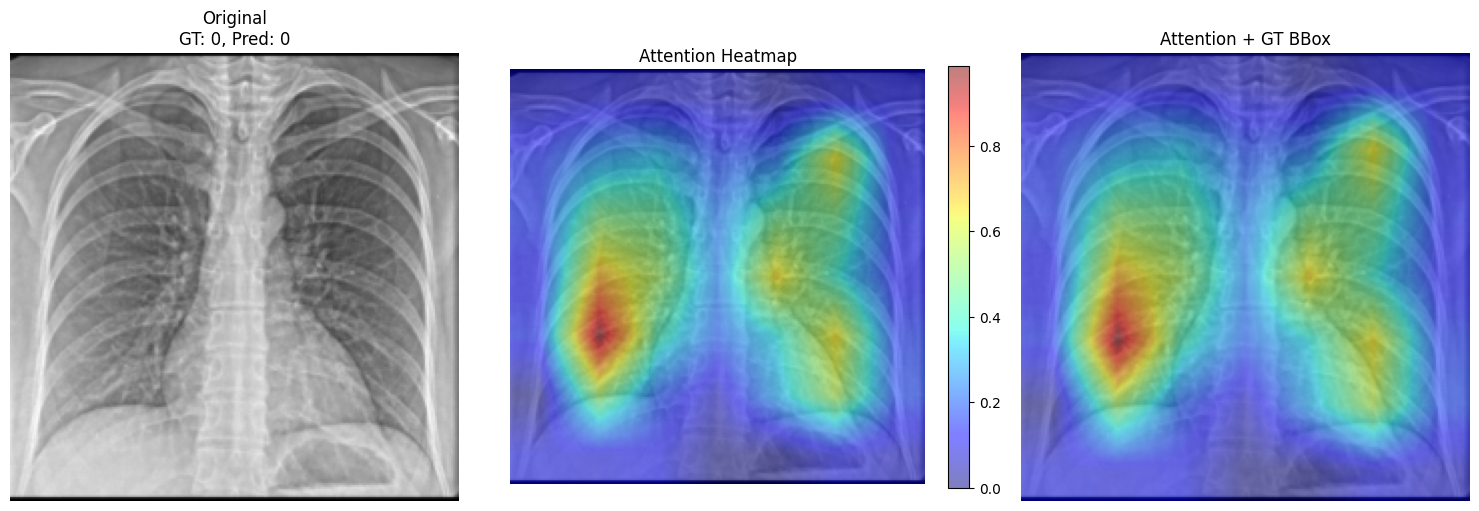

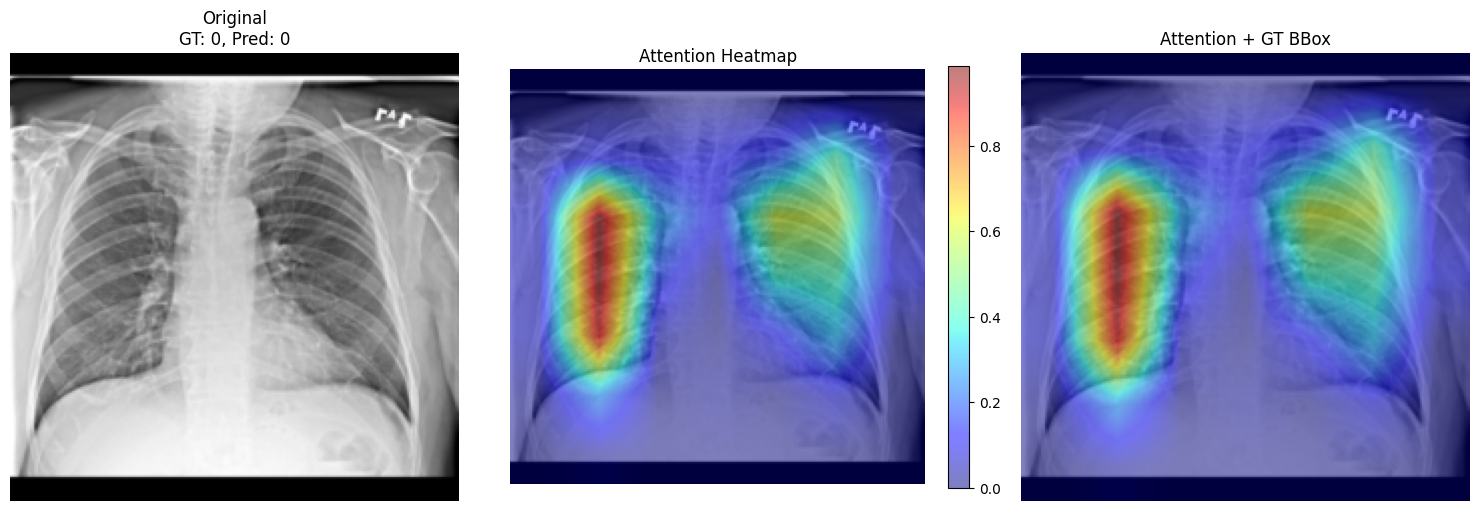

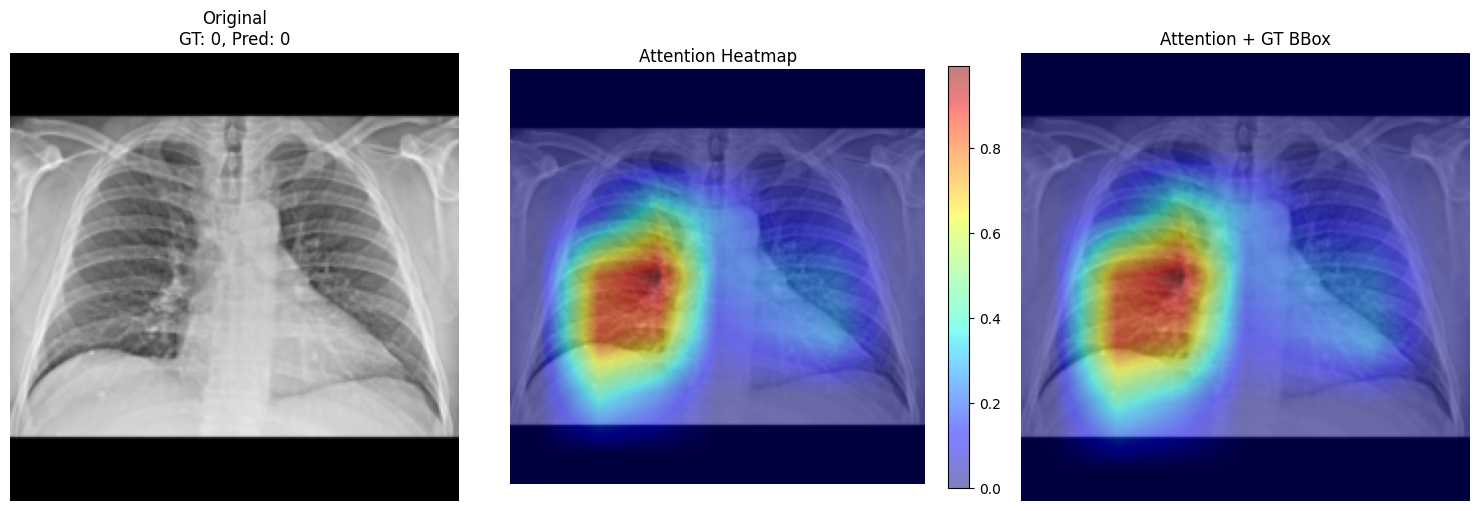

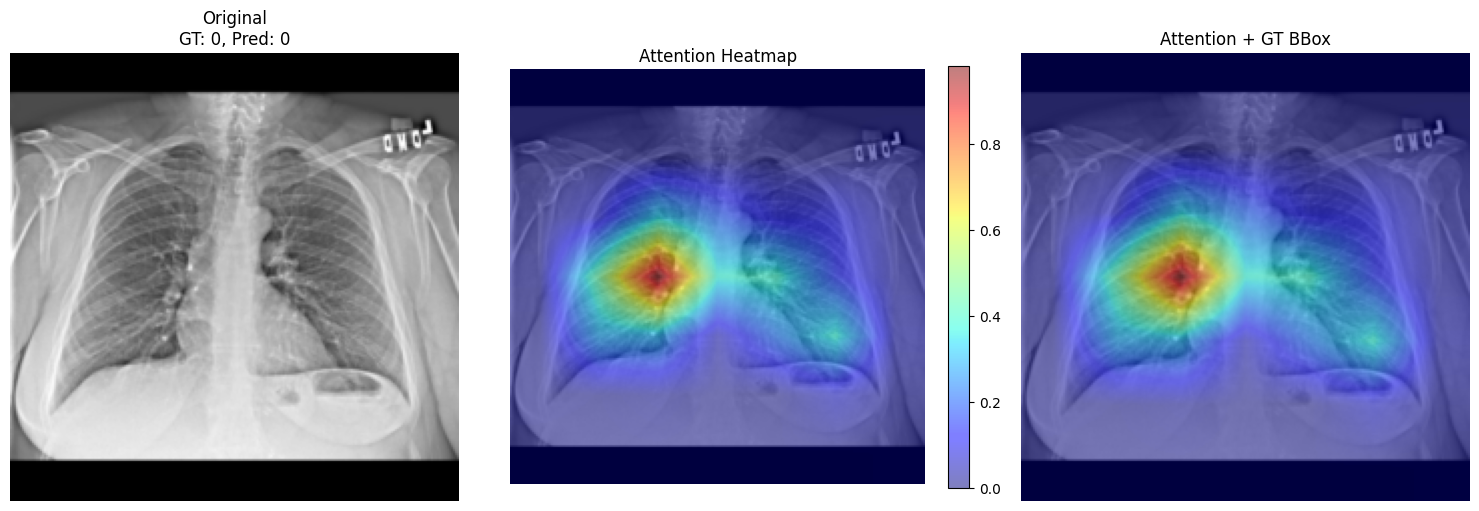

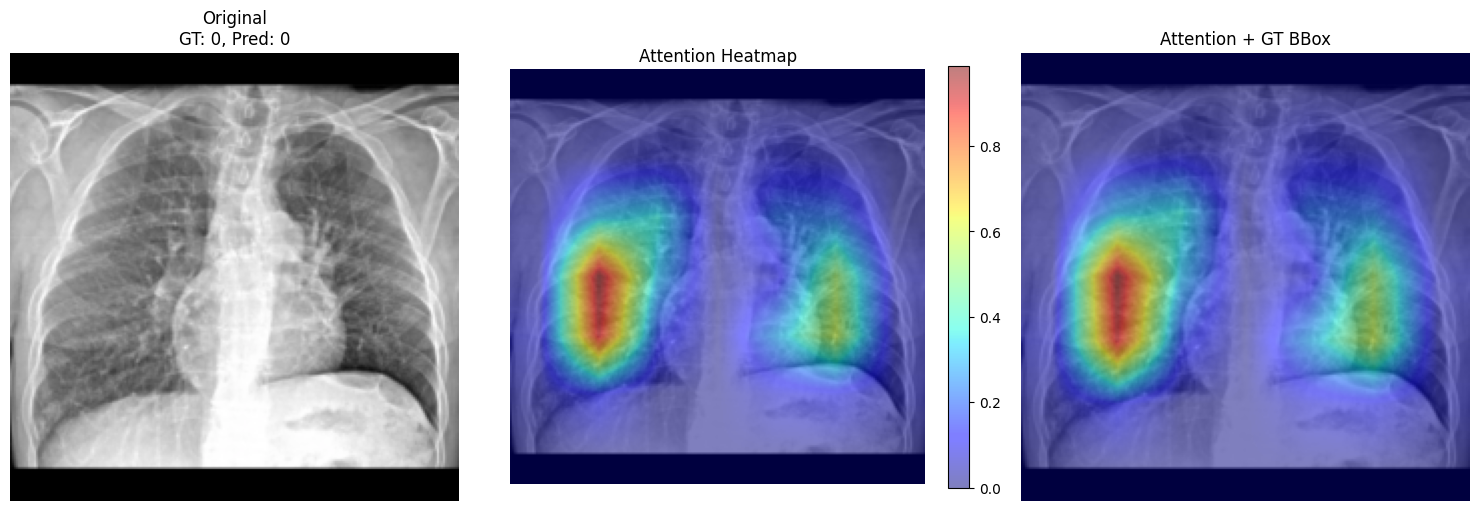

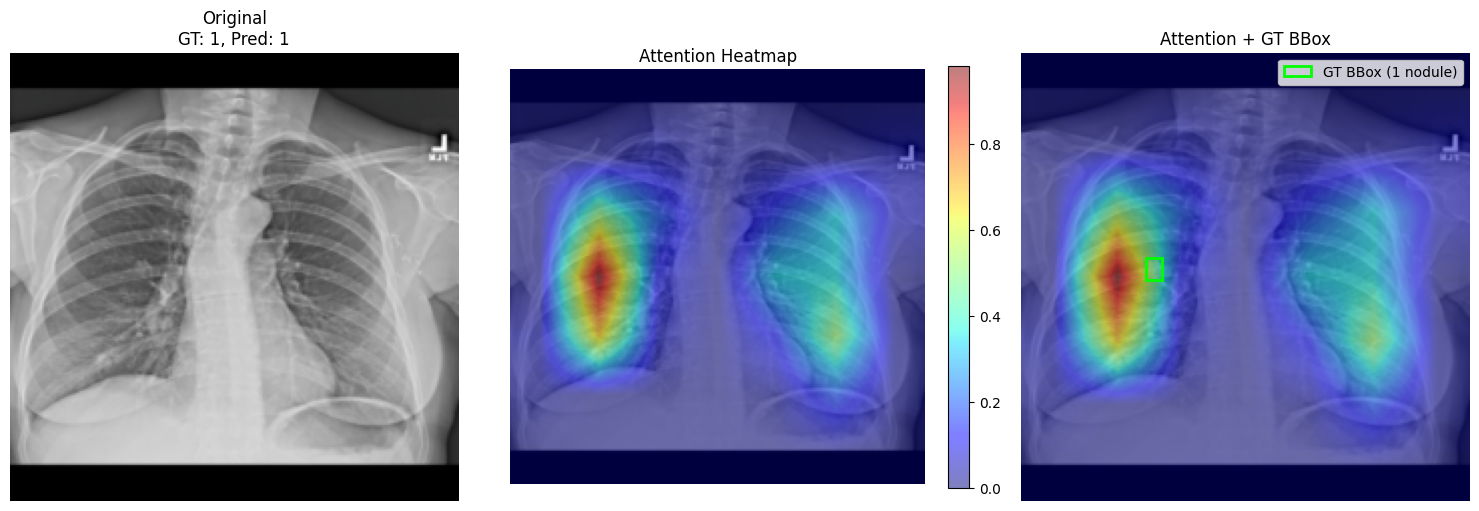


Visualized 6 random test samples with attention maps
Note: Images with multiple nodules will show one bbox per visualization


In [15]:
# ============================================================================
# VISUALIZE ATTENTION MAPS ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("Generating Attention Visualizations on Test Set")
print("=" * 80)

model.eval()

# Get random samples from test dataset
num_samples = 6
random_indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

print(f"Selected random indices: {random_indices}")

for idx in random_indices:
    img, label, bbox = test_dataset[idx]
    
    # Get prediction
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output.argmax(1).item()
    
    # Visualize
    subfig = visualize_attention_with_bbox(model, img, bbox, label, pred)
    plt.show()
    
print(f"\nVisualized {num_samples} random test samples with attention maps")
print("Note: Images with multiple nodules will show one bbox per visualization")



Finding positive samples (with nodules) for visualization...
Found 165 unique positive patients in test set
Visualizing 8 random positive patients...

Patient: n0645.mha
  Added bbox: pixel=[812, 719, 35, 31] -> norm=[0.793, 0.702, 0.034, 0.030]
Found 1 nodule(s)


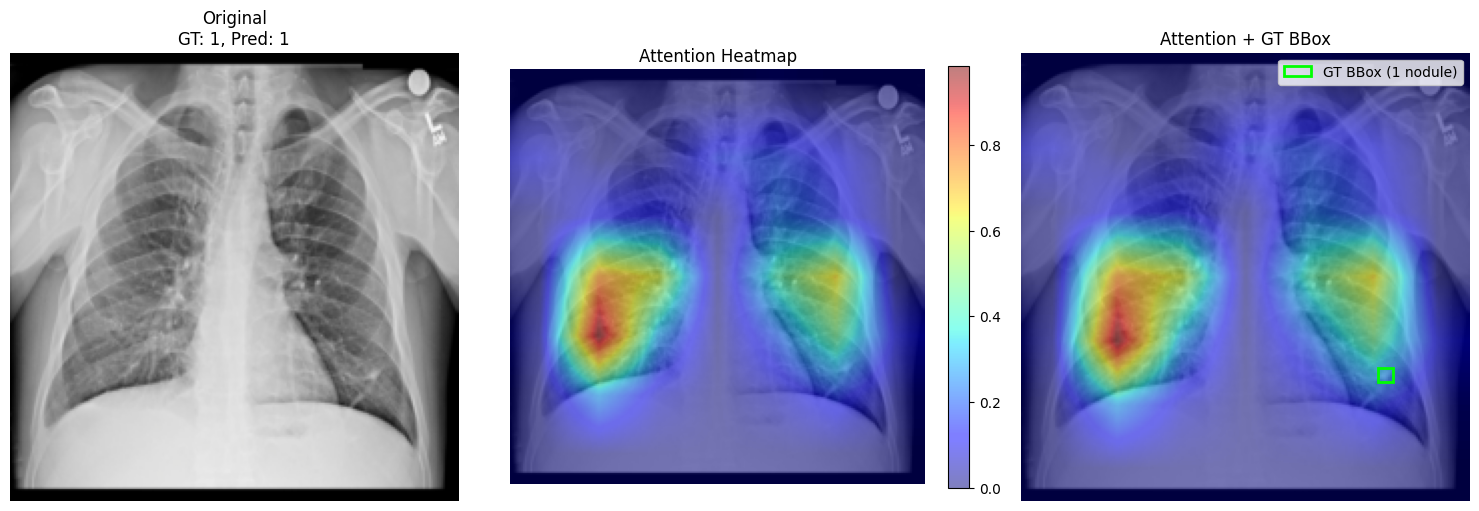


Patient: n0519.mha
  Added bbox: pixel=[236, 784, 70, 70] -> norm=[0.230, 0.766, 0.068, 0.068]
Found 1 nodule(s)


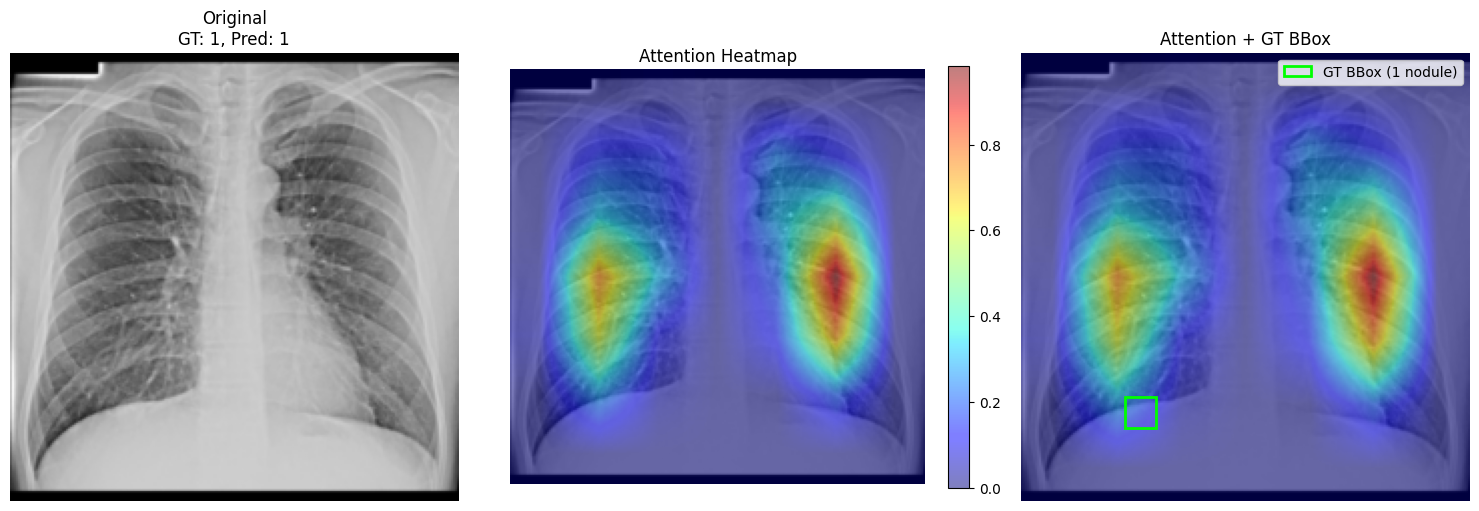


Patient: n0559.mha
  Added bbox: pixel=[138, 532, 46, 59] -> norm=[0.135, 0.520, 0.045, 0.058]
Found 1 nodule(s)


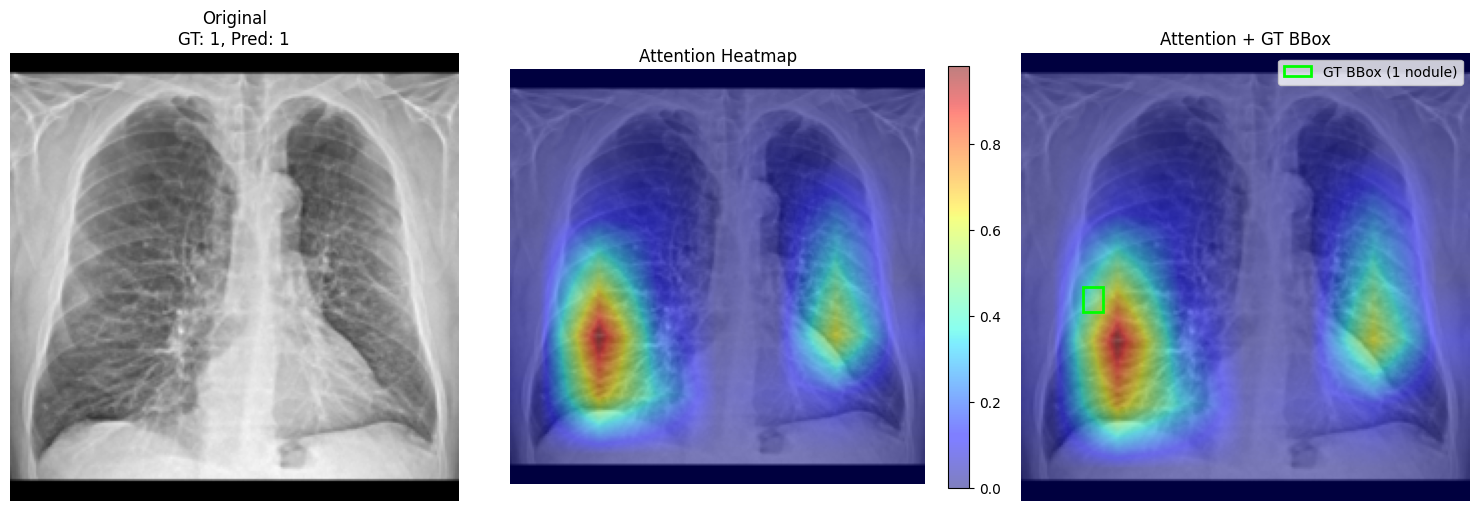


Patient: n0776.mha
  Added bbox: pixel=[203, 352, 49, 58] -> norm=[0.198, 0.344, 0.048, 0.057]
  Added bbox: pixel=[155, 461, 67, 87] -> norm=[0.151, 0.450, 0.065, 0.085]
Found 2 nodule(s)


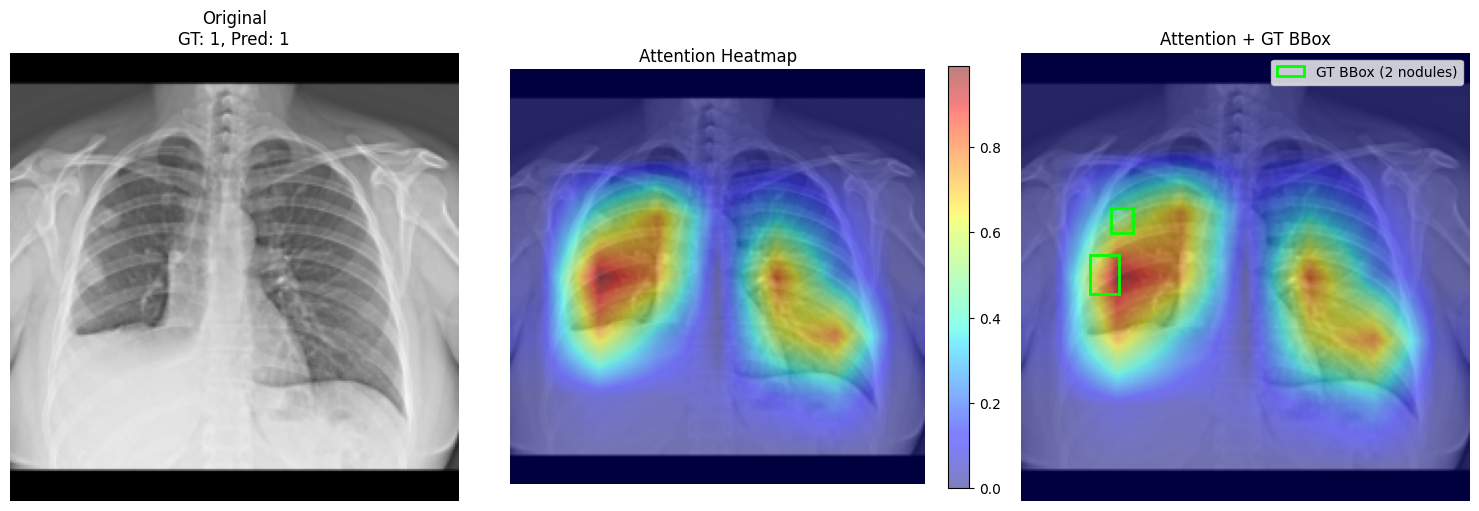


Patient: n0005.mha
  Added bbox: pixel=[144, 485, 57, 75] -> norm=[0.141, 0.474, 0.056, 0.073]
Found 1 nodule(s)


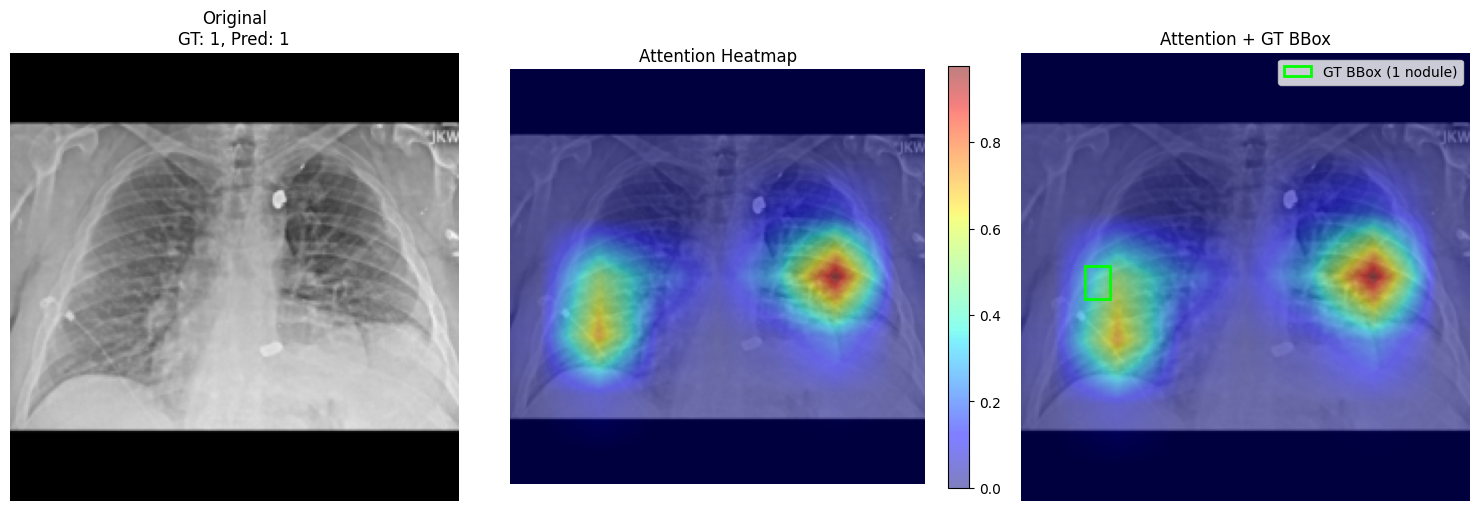


Patient: n0566.mha
  Added bbox: pixel=[137, 396, 63, 88] -> norm=[0.134, 0.387, 0.062, 0.086]
Found 1 nodule(s)


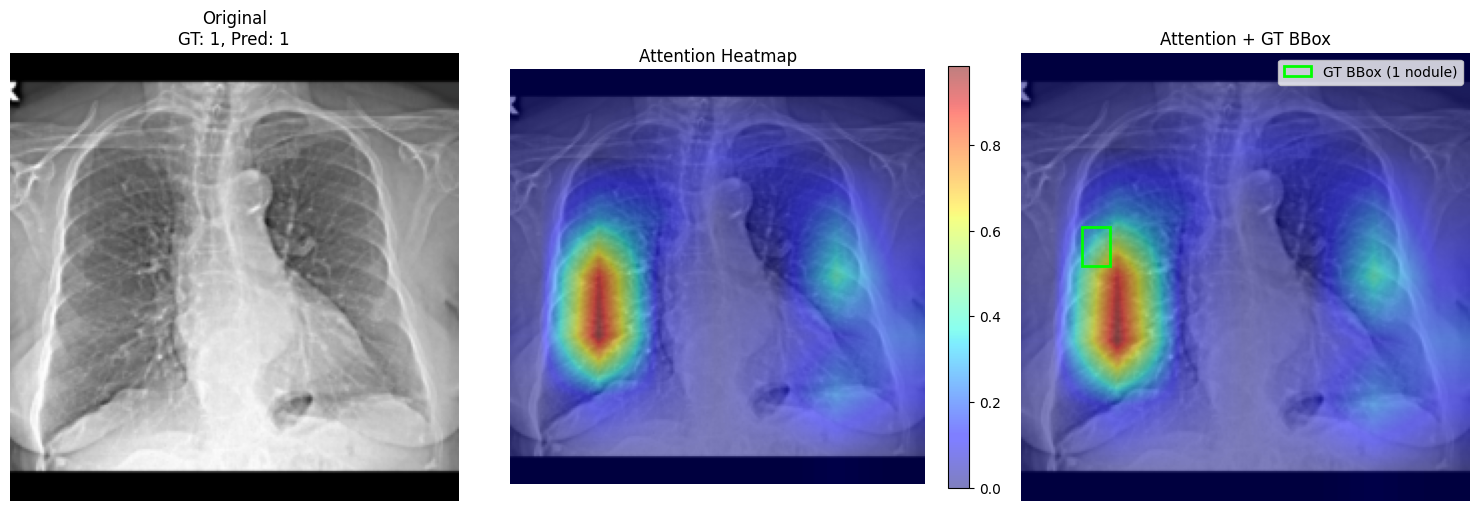


Patient: n0093.mha
  Added bbox: pixel=[189, 489, 76, 71] -> norm=[0.185, 0.478, 0.074, 0.069]
Found 1 nodule(s)


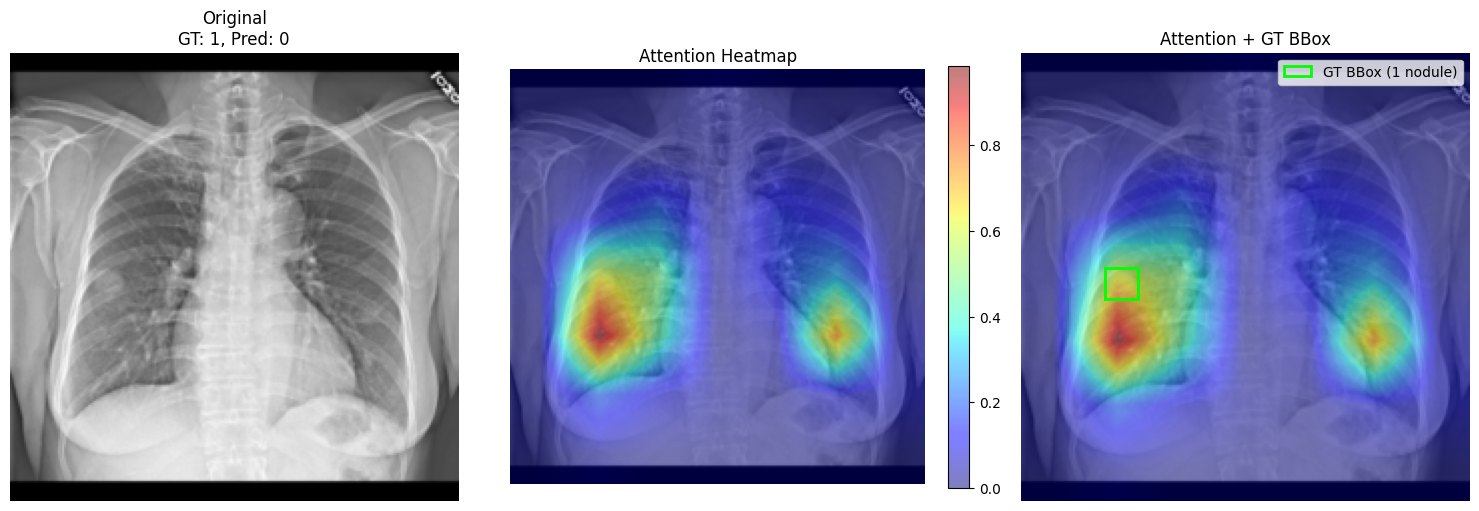


Patient: n1133.mha
  Added bbox: pixel=[751, 641, 49, 47] -> norm=[0.733, 0.626, 0.048, 0.046]
Found 1 nodule(s)


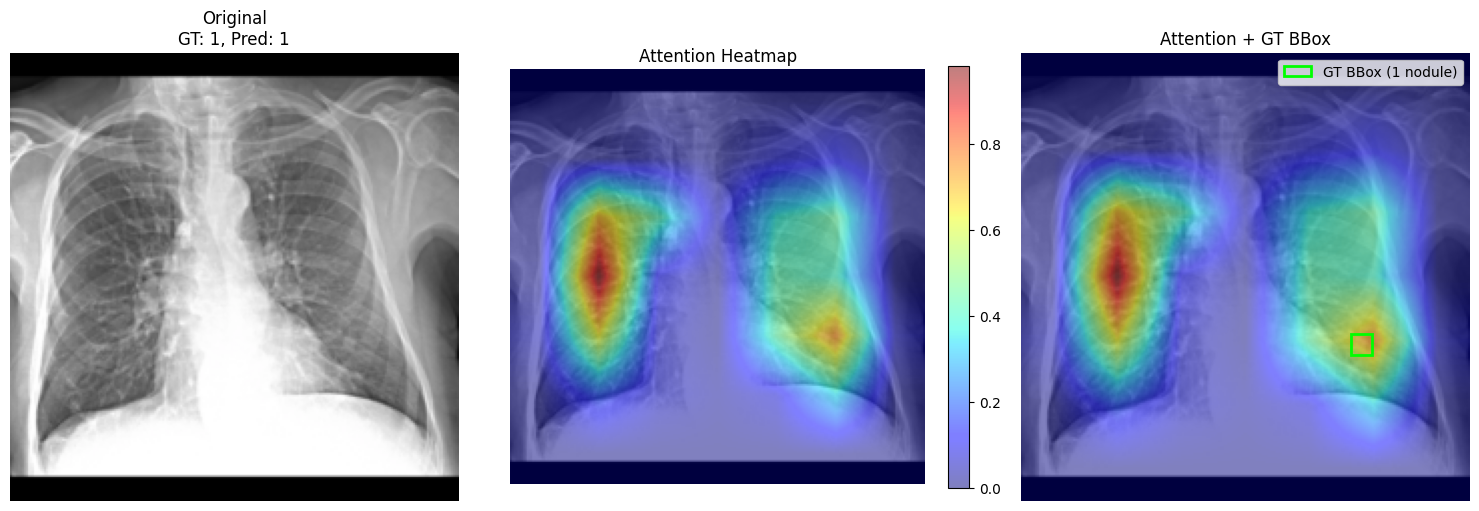


Displayed attention visualizations for 8 unique positive patients
Each visualization shows ALL nodules for that patient

WSOD Fine-tuning Complete!

Best model saved to: best_wsod_resvit.pth
Final Test AUC: 0.9724
Final Test F1: 0.8439


In [19]:
# ============================================================================
# VISUALIZE POSITIVE SAMPLES (NODULES) - WITH MULTIPLE BBOXES PER PATIENT
# ============================================================================

print("\nFinding positive samples (with nodules) for visualization...")

# Find unique positive patients (to avoid showing same patient multiple times)
positive_patients = {}  # {img_name: first_index}
for i in range(len(test_dataset)):
    _, label, _ = test_dataset[i]
    if label == 1:
        img_name = test_df.iloc[i]['img_name']
        if img_name not in positive_patients:
            positive_patients[img_name] = i

print(f"Found {len(positive_patients)} unique positive patients in test set")

# Randomly select up to 8 unique patients
num_vis = min(8, len(positive_patients))
if num_vis > 0:
    selected_patients = np.random.choice(list(positive_patients.keys()), size=num_vis, replace=False)
    print(f"Visualizing {num_vis} random positive patients...")
    
    for patient_name in selected_patients:
        # Get the first index for this patient
        idx = positive_patients[patient_name]
        img, label, _ = test_dataset[idx]
        
        print(f"\nPatient: {patient_name}")
        
        # Find ALL bboxes for this patient from the dataframe
        patient_rows = test_df[test_df['img_name'] == patient_name]
        all_bboxes = []
        
        # Get original image dimensions (assuming square images from your dataset)
        # You may need to adjust this based on your actual image dimensions
        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            # Default assumption - adjust if needed
            img_width = 1024  # Typical X-ray width
            img_height = 1024  # Typical X-ray height
        
        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                # Normalize bbox coordinates to [0, 1]
                x_norm = row['x'] / img_width
                y_norm = row['y'] / img_height
                w_norm = row['width'] / img_width
                h_norm = row['height'] / img_height
                
                bbox_tensor = torch.tensor([
                    x_norm,
                    y_norm,
                    w_norm,
                    h_norm
                ], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, {row['width']:.0f}, {row['height']:.0f}] -> norm=[{x_norm:.3f}, {y_norm:.3f}, {w_norm:.3f}, {h_norm:.3f}]")
        
        print(f"Found {len(all_bboxes)} nodule(s)")
        
        # Get prediction
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        
        # Visualize with ALL bboxes
        subfig = visualize_attention_with_bbox(model, img, all_bboxes, label, pred)
        plt.show()
    
    print(f"\n{'='*80}")
    print(f"Displayed attention visualizations for {num_vis} unique positive patients")
    print(f"Each visualization shows ALL nodules for that patient")
else:
    print("No positive samples found in test set")

print("\n" + "=" * 80)
print("WSOD Fine-tuning Complete!")
print("=" * 80)
print(f"\nBest model saved to: {best_model_path}")
print(f"Final Test AUC: {test_auc:.4f}")
print(f"Final Test F1: {test_f1:.4f}")